In [1]:
!date

Mon Sep 14 12:13:27 PDT 2026


In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, percentileofscore

projdir = '/u/project/cluo/terencew/claude/project_ideas/pool_design'
sys.path.insert(0, f'{projdir}/scripts/ambisim/lib')
from pool_nomination import load_design_data, universe_idx_for, pool_dist_metrics

In [3]:
### does our pool-construction procedure decouple min_dist/mean_dist the way real
### pools do, or does it entangle them? see NOTES.md (github/demux_pool_design) --
### greedy_maxmin/greedy_maxmean are the same greedy point-repulsion algorithm and
### produce 50-60% the same donor list. This notebook quantifies that directly and
### checks whether the new orthogonal-sampling ('_new') pools actually fix it.
D, X, sample_ids, meta = load_design_data()
UNIVERSE = 'EUR_only'
universe_idx = universe_idx_for(UNIVERSE, meta)
len(universe_idx)

525

In [4]:
### existing n=8 grid pools (already simulated, EUR_only) -- min_dist vs mean_dist
### by strategy, restricted to the ones with real demuxlet data
design = pd.read_csv(f'{projdir}/csv/designs/nominated_pools_n8.tsv', sep='\t')
design['poolid'] = design['universe'] + '__' + design['strategy'] + '__rep' + design['rep'].astype(str)
design = design.drop_duplicates('poolid')[['poolid', 'universe', 'strategy', 'min_dist', 'mean_dist']]

summ = pd.read_csv(f'{projdir}/csv/ambisim/pool_summary.csv', sep='\t')
summ = summ[summ['modality'] == 'gex'].drop_duplicates('pool')[['pool']]
existing = summ.merge(design, left_on='pool', right_on='poolid', how='left')
existing_eur = existing[existing['universe'] == UNIVERSE]
existing_eur[['pool', 'strategy', 'min_dist', 'mean_dist']].sort_values('strategy')

,pool,strategy,min_dist,mean_dist
52,EUR_only__adversarial_family__rep1,adversarial_family,74.202423,101.903511
53,EUR_only__adversarial_family__rep2,adversarial_family,75.808968,101.972603
54,EUR_only__adversarial_family__rep3,adversarial_family,74.652527,102.533302
55,EUR_only__adversarial_mindist__rep1,adversarial_mindist,96.705742,99.814377
56,EUR_only__adversarial_mindist__rep2,adversarial_mindist,95.775780,99.210854
57,EUR_only__greedy_maxkl__rep1,greedy_maxkl,109.311485,112.792702
58,EUR_only__greedy_maxkl__rep2,greedy_maxkl,109.940895,113.561577
59,EUR_only__greedy_maxkl__rep3,greedy_maxkl,110.190742,113.522163
60,EUR_only__greedy_maxmean__rep1,greedy_maxmean,108.646220,114.119960
61,EUR_only__greedy_maxmean__rep3,greedy_maxmean,108.041660,113.974610


In [5]:
### quantify entanglement per strategy family
for strat in ['random', 'greedy_maxmin', 'greedy_maxmean']:
    sub = existing_eur[existing_eur['strategy'] == strat]
    print(f'{strat:15s} n={len(sub)}  min_dist mean={sub.min_dist.mean():.1f}  mean_dist mean={sub.mean_dist.mean():.1f}')

### donor overlap between greedy_maxmin and greedy_maxmean, same rep
for rep in [1, 2, 3]:
    f1 = f'{projdir}/txt/donors/{UNIVERSE}__greedy_maxmin__rep{rep}.txt'
    f2 = f'{projdir}/txt/donors/{UNIVERSE}__greedy_maxmean__rep{rep}.txt'
    try:
        d1 = set(open(f1).read().split())
        d2 = set(open(f2).read().split())
        print(f'rep{rep}: {len(d1 & d2)}/8 donors shared between greedy_maxmin and greedy_maxmean')
    except FileNotFoundError:
        pass

random          n=3  min_dist mean=100.2  mean_dist mean=105.4
greedy_maxmin   n=2  min_dist mean=109.8  mean_dist mean=113.2
greedy_maxmean  n=2  min_dist mean=108.3  mean_dist mean=114.0
rep1: 5/8 donors shared between greedy_maxmin and greedy_maxmean
rep2: 5/8 donors shared between greedy_maxmin and greedy_maxmean
rep3: 6/8 donors shared between greedy_maxmin and greedy_maxmean


In [6]:
### donor overlap across ALL universes (not just EUR_only) -- how much of the
### 'different' objective is actually the same people? Figure for the methods
### section: greedy_maxmin and greedy_maxmean should be two distinct design
### philosophies (worst-case vs. average-case optimization), but both are the
### same greedy point-repulsion algorithm with a one-line objective swap.
single_anc = ['AFR_only', 'AMR_only', 'EAS_only', 'EUR_only', 'SAS_only']
multi_anc = ['EUR_AFR', 'EUR_EAS', 'all_3_major', 'all_5']
overlap_rows = []
for uni in single_anc + multi_anc:
    for rep in [1, 2, 3]:
        f1 = f'{projdir}/txt/donors/{uni}__greedy_maxmin__rep{rep}.txt'
        f2 = f'{projdir}/txt/donors/{uni}__greedy_maxmean__rep{rep}.txt'
        try:
            d1 = set(open(f1).read().split())
            d2 = set(open(f2).read().split())
            overlap_rows.append({'universe': uni, 'rep': rep, 'n_shared_of_8': len(d1 & d2),
                                  'universe_type': 'single-ancestry' if uni in single_anc else 'multi-ancestry'})
        except FileNotFoundError:
            pass
overlap_df = pd.DataFrame(overlap_rows).sort_values(['universe_type', 'universe', 'rep'])
print(f'mean donor overlap: {overlap_df.n_shared_of_8.mean():.2f}/8 across {len(overlap_df)} universe x rep combinations')
overlap_df.groupby('universe_type')['n_shared_of_8'].agg(['mean', 'min', 'max', 'count'])

mean donor overlap: 4.81/8 across 27 universe x rep combinations


,mean,min,max,count
universe_type,,,,
multi-ancestry,4.583333,3,7,12
single-ancestry,5.000000,1,7,15


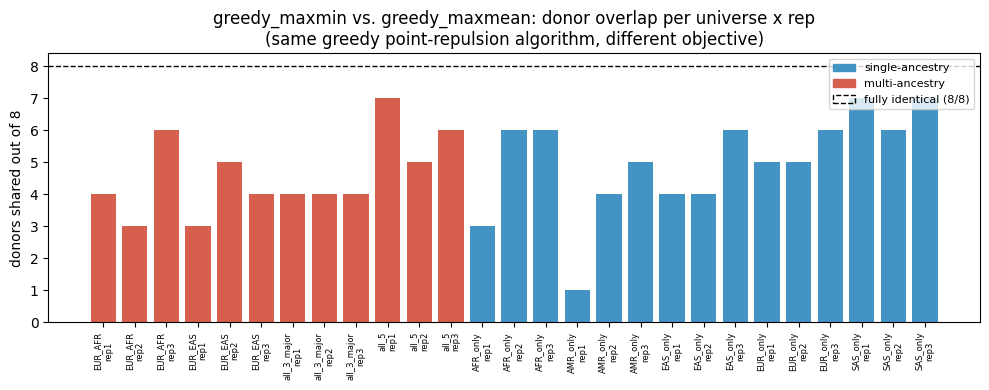

In [7]:
### FIGURE 1: donor overlap bar chart -- greedy_maxmin vs greedy_maxmean
fig, ax = plt.subplots(figsize=(10, 4))
plot_df = overlap_df.reset_index(drop=True)
colors = ['#4393c3' if t == 'single-ancestry' else '#d6604d' for t in plot_df['universe_type']]
labels = [f"{r['universe']}\nrep{r['rep']}" for _, r in plot_df.iterrows()]
ax.bar(range(len(plot_df)), plot_df['n_shared_of_8'], color=colors)
ax.axhline(8, color='black', linestyle='--', linewidth=1, label='fully identical (8/8)')
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_ylabel('donors shared out of 8')
ax.set_title('greedy_maxmin vs. greedy_maxmean: donor overlap per universe x rep\n'
             '(same greedy point-repulsion algorithm, different objective)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4393c3', label='single-ancestry'),
                    Patch(color='#d6604d', label='multi-ancestry'),
                    Patch(facecolor='none', edgecolor='black', linestyle='--', label='fully identical (8/8)')],
          fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(f'{projdir}/figures/00_donor_overlap_greedy.pdf', bbox_inches='tight')
plt.show()

In [8]:
### reference backdrop: what does min_dist vs mean_dist look like for pools with
### NO optimization at all? 200k random 8-donor draws, distance-matrix lookups only
### (no genotype simulation) so this is cheap (~15s). n_draws=200,000 (not 20,000)
### so the convergence-diagnostic figure below can check behavior out to that range.
rng = np.random.default_rng(0)
universe_arr = np.array(universe_idx)
n_draws = 200000
cloud_min, cloud_mean = np.empty(n_draws), np.empty(n_draws)
for i in range(n_draws):
    pool = rng.choice(universe_arr, 8, replace=False)
    m = pool_dist_metrics(list(pool), D)
    cloud_min[i] = m['min_dist']
    cloud_mean[i] = m['mean_dist']

# headline correlation reported at n=20,000 (matches the operating point used
# throughout NOTES.md/README) -- the convergence figure below shows this is
# already stable well before 200,000
r_cloud, p_cloud = pearsonr(cloud_min[:20000], cloud_mean[:20000])
print(f'random-draw cloud (n=20,000 of {n_draws} generated): min_dist vs mean_dist r={r_cloud:.3f} p={p_cloud:.3f}')
print('this is the natural baseline correlation with zero optimization pressure -- compare to')
print('greedy_maxmin/greedy_maxmean r=0.69-0.84 (NOTES.md) and real data r=0.14')

random-draw cloud (n=20,000 of 200000 generated): min_dist vs mean_dist r=0.536 p=0.000
this is the natural baseline correlation with zero optimization pressure -- compare to
greedy_maxmin/greedy_maxmean r=0.69-0.84 (NOTES.md) and real data r=0.14


In [9]:
### ground truth: what does min_dist vs mean_dist actually look like in real,
### non-curated 10x pools? (63 real pools, distinct from anything simulated
### in this repo -- see notebooks/vcf_metrics/01a_expected_ll.ipynb source)
real_srcdir = '/u/project/cluo/terencew/demux_benchmark/pool_design'
real_dists = pd.read_csv(f'{real_srcdir}/csv/50_line/pool_genetic_dists.csv', sep='\t', index_col=0).set_index('sample')
real_eth = pd.read_csv(f'{real_srcdir}/csv/50_line/pool_ancestries.csv', sep='\t', index_col=0)
real_eth.index = real_eth['sample']
real_eth['n_eur'] = (real_eth['eur_prop'] * 6).round().astype(int)

r_real, p_real = pearsonr(real_dists['min'], real_dists['mean'])
r_mean_vs_anc, _ = pearsonr(real_eth.loc[real_dists.index, 'n_eur'], real_dists['mean'])
r_min_vs_anc, _ = pearsonr(real_eth.loc[real_dists.index, 'n_eur'], real_dists['min'])
print(f'REAL DATA (n={len(real_dists)} pools): min_dist vs mean_dist r={r_real:.3f} p={p_real:.3f}')
print(f'  mean_dist vs ancestry ratio (n_eur): r={r_mean_vs_anc:+.3f}  (population-average statistic tracks composition)')
print(f'  min_dist vs ancestry ratio (n_eur):  r={r_min_vs_anc:+.3f}  (extremal statistic does not)')

REAL DATA (n=63 pools): min_dist vs mean_dist r=0.137 p=0.286
  mean_dist vs ancestry ratio (n_eur): r=-0.907  (population-average statistic tracks composition)
  min_dist vs ancestry ratio (n_eur):  r=-0.158  (extremal statistic does not)


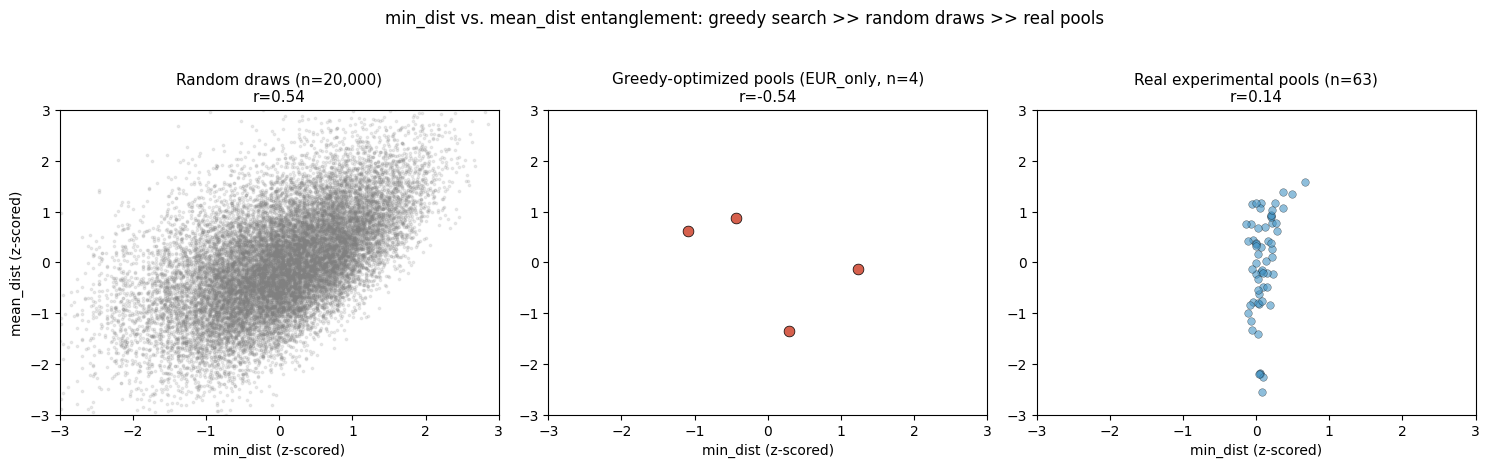

In [10]:
### FIGURE 2: THE key methods figure -- three panels, same axes/scale logic,
### side by side: random simulated draws vs. greedy-optimized simulated pools
### vs. real experimental pools. Makes the entanglement argument visually in
### one glance: greedy pools occupy a narrow, correlated band; real pools
### scatter far more independently; random draws sit in between.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# panel A: random draws -- first 20,000 of the cloud, matching the headline r_cloud
# reported everywhere else in NOTES.md/README (the array holds 200k for the
# convergence figure, but this panel/number pair must stay internally consistent)
plot_min, plot_mean = cloud_min[:20000], cloud_mean[:20000]
z_cloud_min = (plot_min - plot_min.mean()) / plot_min.std()
z_cloud_mean = (plot_mean - plot_mean.mean()) / plot_mean.std()
axes[0].scatter(z_cloud_min, z_cloud_mean, s=3, alpha=0.15, color='gray')
axes[0].set_title(f'Random draws (n=20,000)\nr={r_cloud:.2f}', fontsize=11)

# panel B: greedy-optimized pools (maxmin + maxmean together, EUR_only, matches panel A's universe)
greedy_eur = existing_eur[existing_eur['strategy'].isin(['greedy_maxmin', 'greedy_maxmean'])]
z_g_min = (greedy_eur['min_dist'] - greedy_eur['min_dist'].mean()) / greedy_eur['min_dist'].std()
z_g_mean = (greedy_eur['mean_dist'] - greedy_eur['mean_dist'].mean()) / greedy_eur['mean_dist'].std()
r_greedy_eur, p_greedy_eur = pearsonr(greedy_eur['min_dist'], greedy_eur['mean_dist'])
axes[1].scatter(z_g_min, z_g_mean, s=60, color='#d6604d', edgecolor='black', linewidth=0.5)
axes[1].set_title(f'Greedy-optimized pools (EUR_only, n={len(greedy_eur)})\nr={r_greedy_eur:.2f}', fontsize=11)

# panel C: real experimental pools
z_r_min = (real_dists['min'] - real_dists['min'].mean()) / real_dists['min'].std()
z_r_mean = (real_dists['mean'] - real_dists['mean'].mean()) / real_dists['mean'].std()
axes[2].scatter(z_r_min, z_r_mean, s=30, color='#4393c3', alpha=0.6, edgecolor='black', linewidth=0.3)
axes[2].set_title(f'Real experimental pools (n={len(real_dists)})\nr={r_real:.2f}', fontsize=11)

for ax in axes:
    ax.set_xlabel('min_dist (z-scored)')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
axes[0].set_ylabel('mean_dist (z-scored)')
fig.suptitle('min_dist vs. mean_dist entanglement: greedy search >> random draws >> real pools',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(f'{projdir}/figures/00_entanglement_three_panel.pdf', bbox_inches='tight')
plt.show()

In [11]:
### load the new orthogonal-sampling ('_new') pools and check where they land
### relative to the random cloud -- do they actually achieve disagreement?
new_design = pd.read_csv(f'{projdir}/csv/designs/nominated_pools_new.tsv', sep='\t')
new_design['pool'] = new_design['pool_name']
for _, row in new_design.iterrows():
    pct_min = percentileofscore(cloud_min, row['min_dist'])
    pct_mean = percentileofscore(cloud_mean, row['mean_dist'])
    print(f"{row['pool']:45s} min_dist={row['min_dist']:6.1f} (p{pct_min:5.1f})   "
          f"mean_dist={row['mean_dist']:6.1f} (p{pct_mean:5.1f})   quadrant={row['quadrant']}")

EUR_only__highmin_lowmean_new__rep1           min_dist= 103.4 (p 98.7)   mean_dist= 105.3 (p 43.4)   quadrant=highmin_lowmean
EUR_only__lowmin_highmean_new__rep1           min_dist=  80.6 (p  0.0)   mean_dist= 106.1 (p 74.5)   quadrant=lowmin_highmean
EUR_only__highmin_lowmean_new__rep2           min_dist= 103.1 (p 97.8)   mean_dist= 105.0 (p 33.6)   quadrant=highmin_lowmean
EUR_only__lowmin_highmean_new__rep2           min_dist=  87.2 (p  0.1)   mean_dist= 107.2 (p 95.3)   quadrant=lowmin_highmean


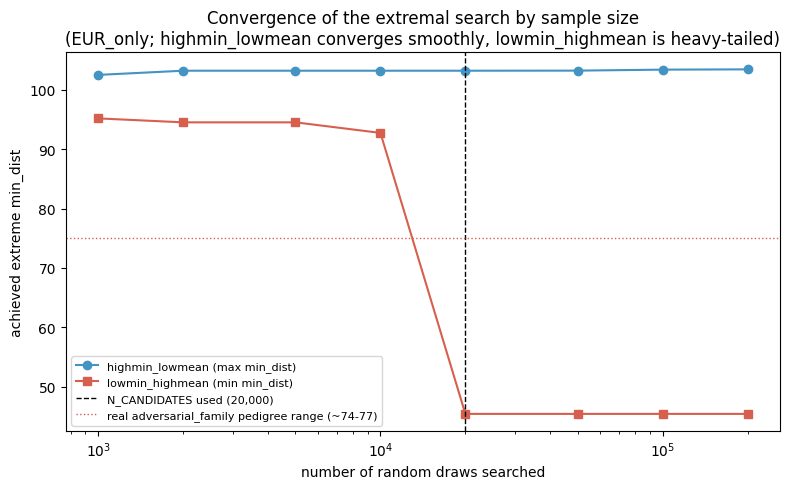

In [12]:
### FIGURE 3: rejection-sampling convergence diagnostic -- justifies
### N_CANDIDATES=20,000 in generate_orthogonal_pools.py and documents the
### asymmetric risk between the two quadrants (see NOTES.md): highmin_lowmean
### converges quickly and smoothly (natural ceiling on how spread out 8
### people can be); lowmin_highmean is heavier-tailed and can approach the
### real adversarial_family pedigree range (~74-77) at higher N, risking
### cryptic relatedness the panel's founder-only 'unrelated' flag won't catch.
checkpoints = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000]
hilo_curve, lohi_curve = [], []
for n_check in checkpoints:
    sub_min = cloud_min[:n_check]; sub_mean = cloud_mean[:n_check]
    med = np.median(sub_mean)
    hilo_curve.append(sub_min[sub_mean <= med].max())
    lohi_curve.append(sub_min[sub_mean >= med].min())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(checkpoints, hilo_curve, 'o-', color='#4393c3', label='highmin_lowmean (max min_dist)')
ax.plot(checkpoints, lohi_curve, 's-', color='#d6604d', label='lowmin_highmean (min min_dist)')
ax.axvline(20000, color='black', linestyle='--', linewidth=1, label='N_CANDIDATES used (20,000)')
ax.axhline(75, color='#d6604d', linestyle=':', linewidth=1,
           label='real adversarial_family pedigree range (~74-77)')
ax.set_xscale('log')
ax.set_xlabel('number of random draws searched')
ax.set_ylabel('achieved extreme min_dist')
ax.set_title('Convergence of the extremal search by sample size\n'
             '(EUR_only; highmin_lowmean converges smoothly, lowmin_highmean is heavy-tailed)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{projdir}/figures/00_rejection_sampling_convergence.pdf', bbox_inches='tight')
plt.show()

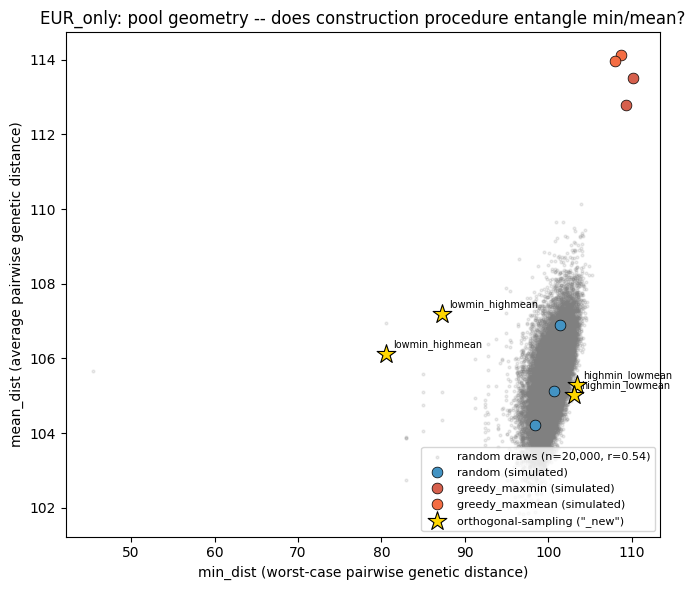

In [13]:
### plot: random cloud (gray) + greedy pools (colored, entangled) + new orthogonal
### pools (stars, should sit off the greedy diagonal in the disagreement corners)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(cloud_min[:20000], cloud_mean[:20000], s=4, alpha=0.15, color='gray',
           label=f'random draws (n=20,000, r={r_cloud:.2f})')

colors = {'random': '#4393c3', 'greedy_maxmin': '#d6604d', 'greedy_maxmean': '#f46d43'}
for strat, color in colors.items():
    sub = existing_eur[existing_eur['strategy'] == strat]
    ax.scatter(sub['min_dist'], sub['mean_dist'], s=60, color=color, label=f'{strat} (simulated)', edgecolor='black', linewidth=0.5)

ax.scatter(new_design['min_dist'], new_design['mean_dist'], s=200, marker='*', color='gold',
           edgecolor='black', linewidth=0.8, label='orthogonal-sampling ("_new")', zorder=5)
for _, row in new_design.iterrows():
    ax.annotate(row['quadrant'], (row['min_dist'], row['mean_dist']), fontsize=7,
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('min_dist (worst-case pairwise genetic distance)')
ax.set_ylabel('mean_dist (average pairwise genetic distance)')
ax.set_title(f'{UNIVERSE}: pool geometry -- does construction procedure entangle min/mean?')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(f'{projdir}/figures/00_pool_geometry_new_pools.pdf', bbox_inches='tight')
plt.show()

In [14]:
### save QC summary for the record
import os
outdir = f'{projdir}/csv/ambisim'
os.makedirs(outdir, exist_ok=True)

qc_rows = [
    {'set': 'random_draw_cloud_n20000', 'n': n_draws, 'min_mean_dist_corr': r_cloud, 'p': p_cloud},
]
for strat in ['random', 'greedy_maxmin', 'greedy_maxmean']:
    sub = existing_eur[existing_eur['strategy'] == strat]
    if len(sub) >= 3:
        r, p = pearsonr(sub['min_dist'], sub['mean_dist'])
        qc_rows.append({'set': strat, 'n': len(sub), 'min_mean_dist_corr': r, 'p': p})

qc_df = pd.DataFrame(qc_rows)
qc_df.to_csv(f'{outdir}/pool_geometry_qc.csv', sep='\t', index=False)
qc_df

,set,n,min_mean_dist_corr,p
0,random_draw_cloud_n20000,200000,0.536363,0.00000
1,random,3,0.882328,0.31195


In [15]:
!date

Mon Sep 14 12:13:53 PDT 2026
